# 02 · Shape, Center, Spread

**Session 2 · Thu Sep 17 · 1 hour (stats half)**

Any distribution can be described by three questions, and almost every descriptive statistic you
will meet is an answer to one of them:

1. **Shape** — what does it look like?
2. **Center** — where is the middle?
3. **Spread** — how spread out is it?

Get these three and you can describe any variable in any dataset in one sentence.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

sns.set_theme(style="whitegrid")
DATA = Path.cwd() / "data" if (Path.cwd() / "data").exists() else Path.cwd().parent / "data"
rng = np.random.default_rng(42)   # same seed => same numbers every time you run this

In [2]:
deposits = pd.read_csv(DATA / "branch_deposits.csv")
lending = pd.read_csv(DATA / "lending.csv")

## 1 · Center: three different "averages"

Three measures of center, and they answer different questions.

In [3]:
x = deposits["balance"]

print(f"mean   (x̄):  ${x.mean():>10,.0f}   <- add everything up, divide by n")
print(f"median:      ${x.median():>10,.0f}   <- sort, take the middle value")
print(f"mode (bin):  ${x.round(-3).mode()[0]:>10,.0f}   <- the most common value (rounded to $1k)")

mean   (x̄):  $    24,072   <- add everything up, divide by n
median:      $     3,888   <- sort, take the middle value
mode (bin):  $     2,000   <- the most common value (rounded to $1k)


**Which one should you use?**

| Use | When | Why |
|---|---|---|
| **Median** | Money, anything skewed | Unmoved by extreme values |
| **Mean** | Symmetric data; when you need totals | It is the only one where `mean × n = total` |
| **Mode** | Categories | "Most common product" makes sense; "mean product" does not |

The mean has one property the median lacks and it is the reason the mean dominates statistics:
`mean × n` recovers the **total**. Your bank cares about total deposits, so the mean is unavoidable
even when it is a poor description of a typical customer. Both facts are true at once, and a careful
analyst reports both numbers.

## 2 · Spread: how much do values vary?

In [4]:
print(f"range:              ${x.max() - x.min():>12,.0f}   (max - min; hostage to one outlier)")
print(f"IQR:                ${x.quantile(.75) - x.quantile(.25):>12,.0f}   (middle 50% -- robust)")
print(f"variance (σ²):      {x.var():>13,.0f}   (in dollars-SQUARED, uninterpretable)")
print(f"std deviation (σ):  ${x.std():>12,.0f}   (back in dollars -- interpretable)")

range:              $     897,434   (max - min; hostage to one outlier)
IQR:                $       5,404   (middle 50% -- robust)
variance (σ²):      11,283,906,792   (in dollars-SQUARED, uninterpretable)
std deviation (σ):  $     106,226   (back in dollars -- interpretable)


### Why variance exists at all

Variance is the average squared distance from the mean. Squared *dollars* are meaningless as a unit,
so why bother?

Because we need distances to be positive. Distances from the mean cancel out to exactly zero by
definition — that is what "mean" means. Squaring fixes the sign, and squares are mathematically far
better behaved than absolute values (they are smooth and differentiable, which matters enormously
once you get to machine learning and gradient descent).

Then we take the square root to return to dollars, and call it the **standard deviation**. So:

> **variance = the mathematically convenient one. standard deviation = the interpretable one.**

They carry identical information. Report `σ`; the machinery uses `σ²`.

In [5]:
# Proof that deviations cancel to zero -- this is why we square them.
deviations = x - x.mean()
print(f"sum of raw deviations:     {deviations.sum():>20,.6f}   <- zero (floating-point dust)")
print(f"sum of SQUARED deviations: {(deviations**2).sum():>20,.0f}   <- something to work with")

sum of raw deviations:                -0.000000   <- zero (floating-point dust)
sum of SQUARED deviations:   13,529,404,243,255   <- something to work with


## 3 · Shape: learn to recognise these four

Shape is the one you assess by eye. Four shapes cover most of what you will meet.

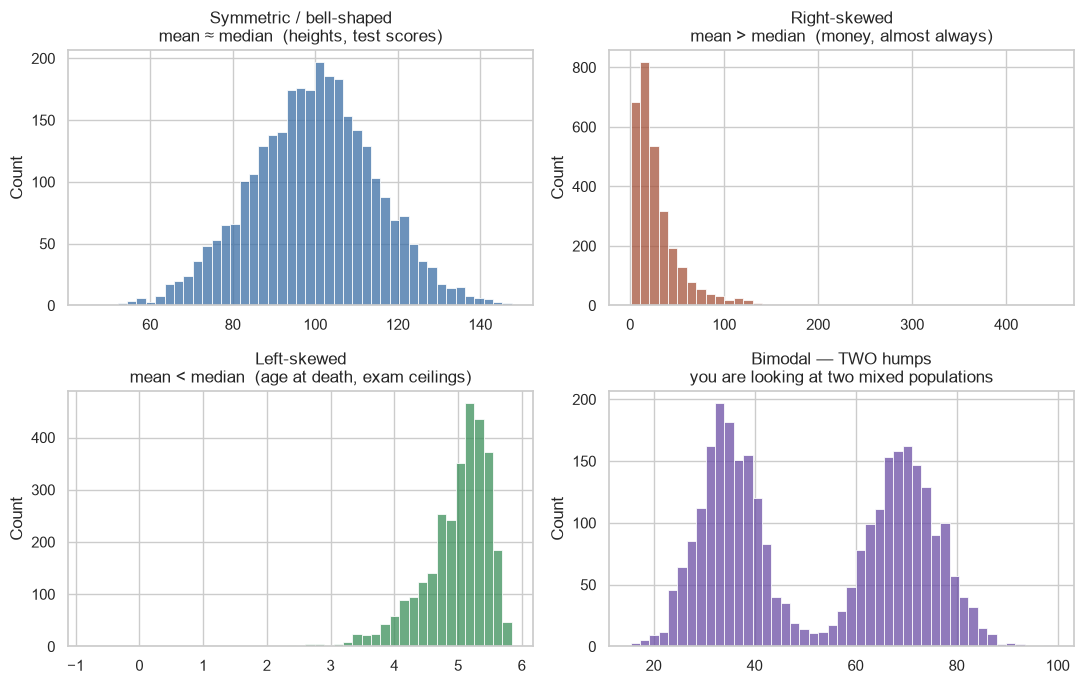

In [6]:
fig, axes = plt.subplots(2, 2, figsize=(11, 7))

sns.histplot(rng.normal(100, 15, 3000), bins=45, ax=axes[0, 0], color="#3b6ea5")
axes[0, 0].set_title("Symmetric / bell-shaped\nmean ≈ median  (heights, test scores)")

sns.histplot(rng.lognormal(3, .9, 3000), bins=45, ax=axes[0, 1], color="#a5533b")
axes[0, 1].set_title("Right-skewed\nmean > median  (money, almost always)")

sns.histplot(6 - rng.lognormal(1, .5, 3000) / 3, bins=45, ax=axes[1, 0], color="#3b8f5a")
axes[1, 0].set_title("Left-skewed\nmean < median  (age at death, exam ceilings)")

sns.histplot(np.concatenate([rng.normal(35, 6, 1500), rng.normal(70, 7, 1500)]),
             bins=45, ax=axes[1, 1], color="#6b4ea5")
axes[1, 1].set_title("Bimodal — TWO humps\nyou are looking at two mixed populations")

plt.tight_layout(); plt.show()

### The one that should make you stop work

**Bimodal.** Two humps almost always means you have accidentally combined two different populations
— two products, two customer segments, two branches with different policies, or data from before and
after a process change.

Summarising a bimodal distribution with a single mean produces a number describing *nobody*. If the
two humps sit at 35 and 70, the mean lands near 52, where there is hardly any data at all.

When you see two humps, the correct next move is not to compute a statistic. It is to ask **"what
variable am I missing?"** — then split on it and describe each group separately.

## 4 · Skew, as a number

Your eye is good at skew, but you can also just measure it.

In [7]:
for col in ["balance", "tenure_years"]:
    s = deposits[col]
    print(f"{col:15s} skew = {s.skew():>6.2f}   mean/median = {s.mean()/s.median():.2f}x")

print()
print("rule of thumb:  |skew| < 0.5 roughly symmetric | 0.5-1 moderate | > 1 strong")

balance         skew =   6.02   mean/median = 6.19x
tenure_years    skew =   1.53   mean/median = 1.17x

rule of thumb:  |skew| < 0.5 roughly symmetric | 0.5-1 moderate | > 1 strong


## Your turn

**Exercise 1.** For `annual_income` in the `lending` data: report mean, median, and skew, and say in
one sentence which measure of center you would put in a report and why.

In [8]:
# your code here

In [ ]:
inc = lending["annual_income"]
print(f"mean   ${inc.mean():,.0f}")
print(f"median ${inc.median():,.0f}")
print(f"skew   {inc.skew():.2f}")
# Mildly right-skewed -- mean and median are close, so either works. I'd report the
# median for "a typical applicant" and the mean if I needed to recover total income.

**Exercise 2.** Plot `credit_score` split by `applicant_group` (hint: `hue="applicant_group"`).
What do you see, and what question does it raise?

In [10]:
# your code here

In [ ]:
fig, ax = plt.subplots(figsize=(9, 4.5))
sns.histplot(data=lending, x="credit_score", hue="applicant_group",
             bins=45, alpha=.55, ax=ax)
ax.set_title("Credit score by applicant group")
plt.show()

print(lending.groupby("applicant_group")["credit_score"].agg(["count","mean","median"]).round(1))

# Group B's distribution sits visibly to the LEFT -- lower scores on average.
#
# The question this raises is the whole of PhDAI 832: is that difference a fact about
# creditworthiness, or a fact about how the historical data was generated? A model trained
# on this data will produce different outcomes by group WITHOUT ever using group as an
# input, because the features it does use carry the disparity. That is exactly what
# "historical bias" means, and you cannot fix it by deleting the group column.

## What you did today

- Three centers (mean/median/mode) and when each is the honest choice.
- Why variance is squared, and why you report the standard deviation instead.
- Four shapes by sight — and why **bimodal** means stop and find your missing variable.
- Saw a group disparity in real-shaped data, which is the bridge into your ethics course.

**Next:** `03_distribution_zoo.ipynb` — generating distributions yourself until the shapes are obvious.